In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 5000

df = pd.DataFrame({
    "transaction_id": range(100001, 100001 + n),
    "amount": np.round(np.random.uniform(100, 100000, n), 2),
    "merchant_category": np.random.choice(
        ["Shopping", "Food", "Travel", "Electronics", "Entertainment", "Healthcare"],
        n
    ),
    "payment_method": np.random.choice(
        ["Credit Card", "Debit Card", "UPI", "Net Banking"],
        n
    ),
    "location": np.random.choice(
        ["Chennai", "Bangalore", "Mumbai", "Delhi", "Hyderabad", "Pune"],
        n
    ),
    "device_type": np.random.choice(
        ["Mobile", "Laptop", "Tablet"],
        n
    ),
    "transaction_frequency": np.random.randint(1, 20, n),
    "account_age_days": np.random.randint(30, 2500, n),
    "previous_transaction_amount": np.round(
        np.random.uniform(100, 80000, n), 2
    ),
    "international_transaction": np.random.choice(
        [0, 1], n, p=[0.85, 0.15]
    ),
    "failed_attempts": np.random.randint(0, 6, n)
})

df.head()

,transaction_id,amount,merchant_category,payment_method,location,device_type,transaction_frequency,account_age_days,previous_transaction_amount,international_transaction,failed_attempts
0,100001,37516.56,Travel,UPI,Delhi,Tablet,17,370,10075.97,0,2
1,100002,95076.36,Travel,UPI,Bangalore,Laptop,17,1514,67103.16,0,5
2,100003,73226.19,Healthcare,Net Banking,Bangalore,Mobile,17,1445,60783.00,0,3
3,100004,59905.98,Electronics,UPI,Delhi,Laptop,16,1590,6018.48,0,3
4,100005,15686.26,Travel,Credit Card,Bangalore,Laptop,8,1604,66924.39,0,2


In [2]:
fraud_score = (
    (df["amount"] > 70000).astype(int) +
    (df["international_transaction"] == 1).astype(int) +
    (df["failed_attempts"] >= 3).astype(int) +
    (df["transaction_frequency"] >= 15).astype(int)
)

df["fraud"] = (fraud_score >= 2).astype(int)

df.head()

,transaction_id,amount,merchant_category,payment_method,location,device_type,transaction_frequency,account_age_days,previous_transaction_amount,international_transaction,failed_attempts,fraud
0,100001,37516.56,Travel,UPI,Delhi,Tablet,17,370,10075.97,0,2,0
1,100002,95076.36,Travel,UPI,Bangalore,Laptop,17,1514,67103.16,0,5,1
2,100003,73226.19,Healthcare,Net Banking,Bangalore,Mobile,17,1445,60783.00,0,3,1
3,100004,59905.98,Electronics,UPI,Delhi,Laptop,16,1590,6018.48,0,3,1
4,100005,15686.26,Travel,Credit Card,Bangalore,Laptop,8,1604,66924.39,0,2,0


In [3]:
df["fraud"].value_counts()

fraud
0    3250
1    1750
Name: count, dtype: int64

In [4]:
df.to_csv("fraud_detection_dataset.csv", index=False)

print("Dataset created successfully!")

Dataset created successfully!


In [5]:
# ==========================================
# STEP 2 - DATA UNDERSTANDING
# ==========================================

print("========== DATASET SHAPE ==========")
print("Rows and Columns:", df.shape)

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

print("\n========== FIRST 5 RECORDS ==========")
display(df.head())

print("\n========== DATA TYPES & INFO ==========")
df.info()

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== DUPLICATE RECORDS ==========")
print("Duplicate rows:", df.duplicated().sum())

print("\n========== FRAUD DISTRIBUTION ==========")
print(df["fraud"].value_counts())

print("\n========== FRAUD PERCENTAGE ==========")
print((df["fraud"].value_counts(normalize=True) * 100).round(2))

print("\n========== NUMERICAL SUMMARY ==========")
display(df.describe())

========== DATASET SHAPE ==========
Rows and Columns: (5000, 12)

========== COLUMN NAMES ==========
['transaction_id', 'amount', 'merchant_category', 'payment_method', 'location', 'device_type', 'transaction_frequency', 'account_age_days', 'previous_transaction_amount', 'international_transaction', 'failed_attempts', 'fraud']

========== FIRST 5 RECORDS ==========


,transaction_id,amount,merchant_category,payment_method,location,device_type,transaction_frequency,account_age_days,previous_transaction_amount,international_transaction,failed_attempts,fraud
0,100001,37516.56,Travel,UPI,Delhi,Tablet,17,370,10075.97,0,2,0
1,100002,95076.36,Travel,UPI,Bangalore,Laptop,17,1514,67103.16,0,5,1
2,100003,73226.19,Healthcare,Net Banking,Bangalore,Mobile,17,1445,60783.00,0,3,1
3,100004,59905.98,Electronics,UPI,Delhi,Laptop,16,1590,6018.48,0,3,1
4,100005,15686.26,Travel,Credit Card,Bangalore,Laptop,8,1604,66924.39,0,2,0



========== DATA TYPES & INFO ==========
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   transaction_id               5000 non-null   int64  
 1   amount                       5000 non-null   float64
 2   merchant_category            5000 non-null   str    
 3   payment_method               5000 non-null   str    
 4   location                     5000 non-null   str    
 5   device_type                  5000 non-null   str    
 6   transaction_frequency        5000 non-null   int32  
 7   account_age_days             5000 non-null   int32  
 8   previous_transaction_amount  5000 non-null   float64
 9   international_transaction    5000 non-null   int64  
 10  failed_attempts              5000 non-null   int32  
 11  fraud                        5000 non-null   int64  
dtypes: float64(2), int32(3), int64(3), str(4)
memo

,transaction_id,amount,transaction_frequency,account_age_days,previous_transaction_amount,international_transaction,failed_attempts,fraud
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,102500.500000,49733.515866,10.025400,1251.810800,40591.825590,0.143400,2.527600,0.350000
std,1443.520003,28934.401709,5.450532,713.330673,22879.362374,0.350515,1.708866,0.477017
min,100001.000000,101.160000,1.000000,30.000000,101.640000,0.000000,0.000000,0.000000
25%,101250.750000,24461.897500,5.000000,631.000000,21026.730000,0.000000,1.000000,0.000000
50%,102500.500000,50050.860000,10.000000,1244.000000,41089.635000,0.000000,3.000000,0.000000
75%,103750.250000,74835.275000,15.000000,1869.250000,60275.137500,0.000000,4.000000,1.000000
max,105000.000000,99971.800000,19.000000,2499.000000,79997.910000,1.000000,5.000000,1.000000


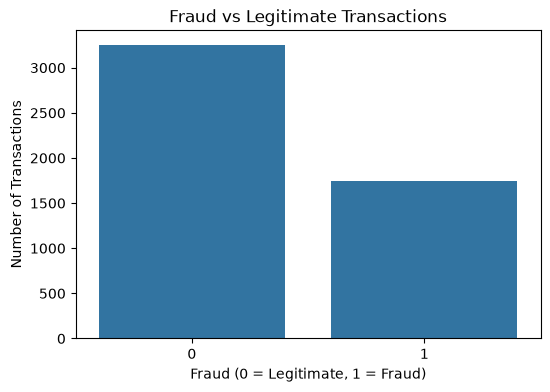

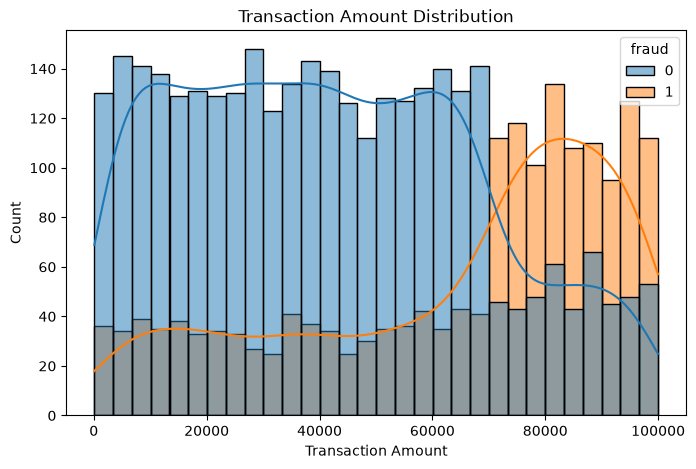

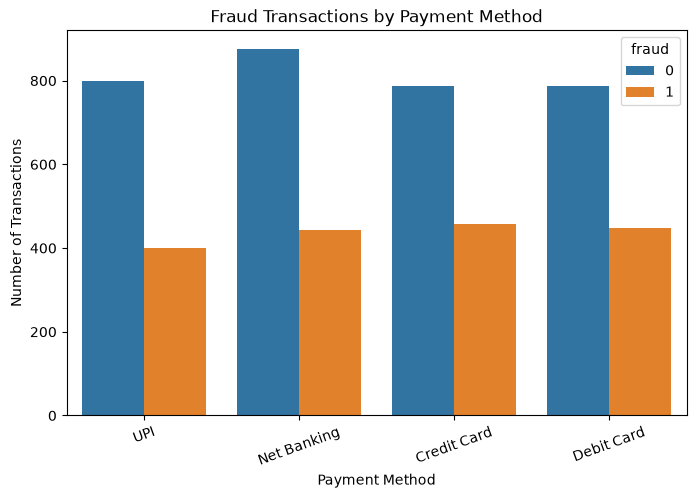

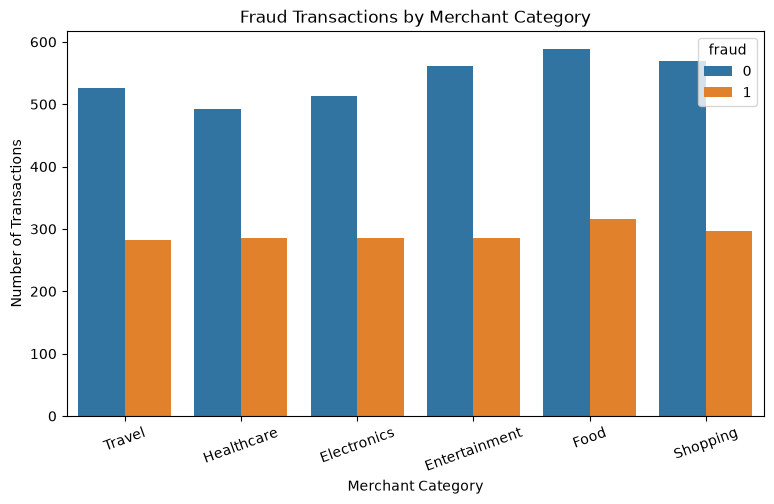

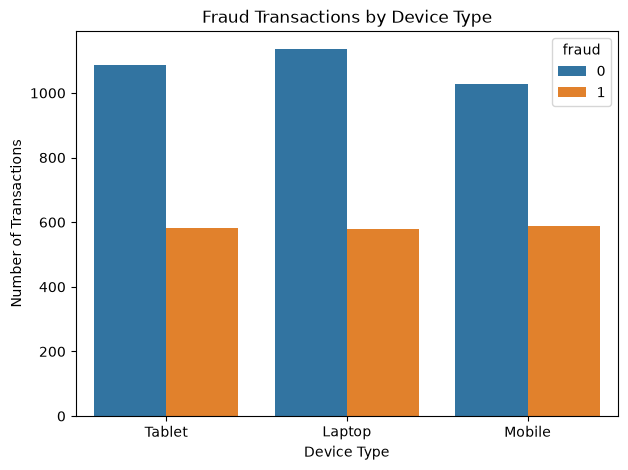

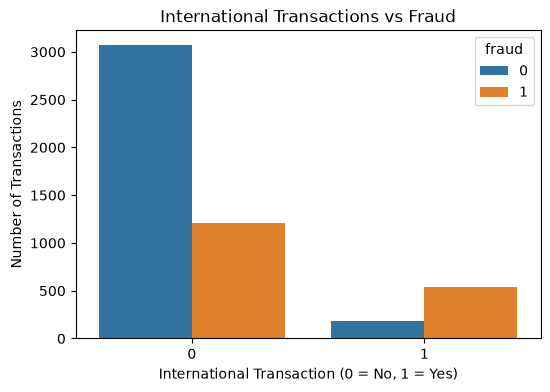

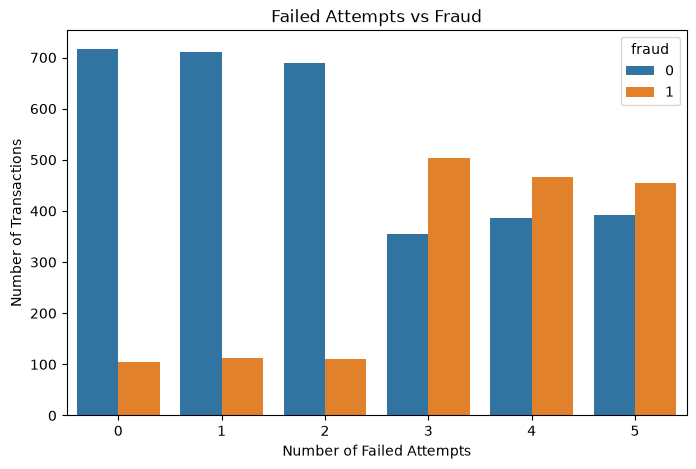

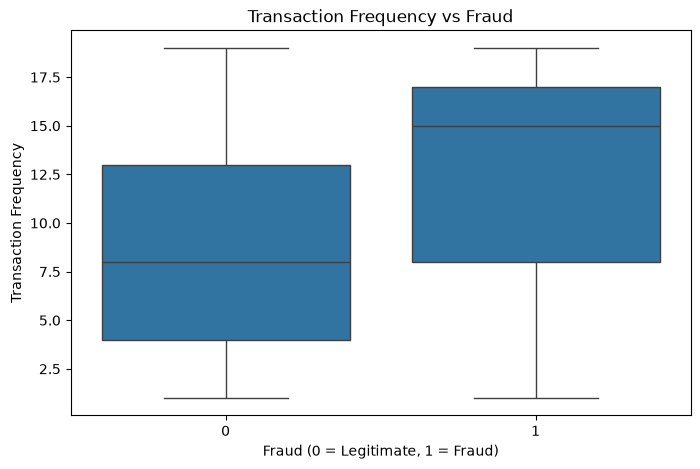

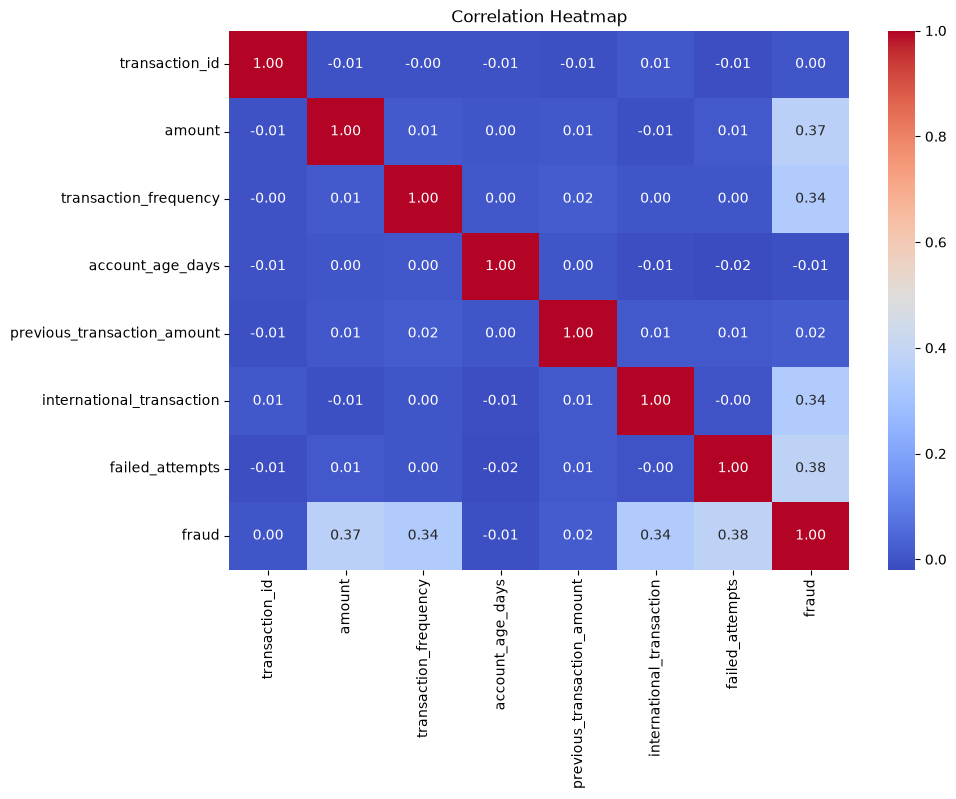

In [6]:
# ==========================================
# STEP 3 - EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fraud vs Legitimate Transactions
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="fraud")
plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()


# 2. Transaction Amount Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="amount", hue="fraud", bins=30, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")
plt.show()


# 3. Fraud by Payment Method
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="payment_method", hue="fraud")
plt.title("Fraud Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=20)
plt.show()


# 4. Fraud by Merchant Category
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="merchant_category", hue="fraud")
plt.title("Fraud Transactions by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=20)
plt.show()


# 5. Fraud by Device Type
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="device_type", hue="fraud")
plt.title("Fraud Transactions by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Number of Transactions")
plt.show()


# 6. International Transaction vs Fraud
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="international_transaction", hue="fraud")
plt.title("International Transactions vs Fraud")
plt.xlabel("International Transaction (0 = No, 1 = Yes)")
plt.ylabel("Number of Transactions")
plt.show()


# 7. Failed Attempts vs Fraud
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="failed_attempts", hue="fraud")
plt.title("Failed Attempts vs Fraud")
plt.xlabel("Number of Failed Attempts")
plt.ylabel("Number of Transactions")
plt.show()


# 8. Transaction Frequency vs Fraud
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="fraud", y="transaction_frequency")
plt.title("Transaction Frequency vs Fraud")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Frequency")
plt.show()


# 9. Correlation Heatmap
plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [7]:
# ==========================================
# STEP 4 - DATA PREPROCESSING
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Create a copy
data = df.copy()

# 1. Remove unnecessary ID column
data = data.drop("transaction_id", axis=1)

# 2. Check missing values
print("Missing values before cleaning:")
print(data.isnull().sum())

# 3. Handle missing values
data = data.dropna()

# 4. Convert categorical columns into numerical values
categorical_columns = [
    "merchant_category",
    "payment_method",
    "location",
    "device_type"
]

label_encoders = {}

for column in categorical_columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# 5. Separate features and target
X = data.drop("fraud", axis=1)
y = data["fraud"]

# 6. Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 7. Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8. Display results
print("\n========== PREPROCESSING COMPLETED ==========")
print("Original dataset shape:", df.shape)
print("Processed dataset shape:", data.shape)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nFeature columns:")
print(X.columns.tolist())

Missing values before cleaning:
amount                         0
merchant_category              0
payment_method                 0
location                       0
device_type                    0
transaction_frequency          0
account_age_days               0
previous_transaction_amount    0
international_transaction      0
failed_attempts                0
fraud                          0
dtype: int64

========== PREPROCESSING COMPLETED ==========
Original dataset shape: (5000, 12)
Processed dataset shape: (5000, 11)

Training data shape: (4000, 10)
Testing data shape: (1000, 10)

Training target distribution:
fraud
0    2600
1    1400
Name: count, dtype: int64

Testing target distribution:
fraud
0    650
1    350
Name: count, dtype: int64

Feature columns:
['amount', 'merchant_category', 'payment_method', 'location', 'device_type', 'transaction_frequency', 'account_age_days', 'previous_transaction_amount', 'international_transaction', 'failed_attempts']


In [8]:
# ==========================================
# STEP 5 - ML MODEL TRAINING & EVALUATION
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------
# 1. Logistic Regression
# ------------------------------------------

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)


# ------------------------------------------
# 2. Random Forest
# ------------------------------------------

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

random_forest_pred = random_forest_model.predict(X_test)


# ------------------------------------------
# 3. Evaluation Function
# ------------------------------------------

def evaluate_model(model_name, y_test, predictions):

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    print("\n================================")
    print(model_name)
    print("================================")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        predictions,
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions))


# ------------------------------------------
# 4. Evaluate Logistic Regression
# ------------------------------------------

evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred
)


# ------------------------------------------
# 5. Evaluate Random Forest
# ------------------------------------------

evaluate_model(
    "Random Forest",
    y_test,
    random_forest_pred
)


Logistic Regression
Accuracy  : 0.8460
Precision : 0.7952
Recall    : 0.7543
F1 Score  : 0.7742

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       650
           1       0.80      0.75      0.77       350

    accuracy                           0.85      1000
   macro avg       0.83      0.82      0.83      1000
weighted avg       0.84      0.85      0.85      1000

Confusion Matrix:
[[582  68]
 [ 86 264]]

Random Forest
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       650
           1       1.00      1.00      1.00       350

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Confusion Matrix:
[[650   0]
 [  0 350]]


========== MODEL COMPARISON ==========


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.846,0.7952,0.7543,0.7742
1,Random Forest,1.000,1.0000,1.0000,1.0000



========== FEATURE IMPORTANCE ==========


,Feature,Importance
0,amount,0.271766
9,failed_attempts,0.264199
5,transaction_frequency,0.242803
8,international_transaction,0.162538
7,previous_transaction_amount,0.018754
6,account_age_days,0.018452
1,merchant_category,0.006475
3,location,0.005993
2,payment_method,0.005217
4,device_type,0.003803


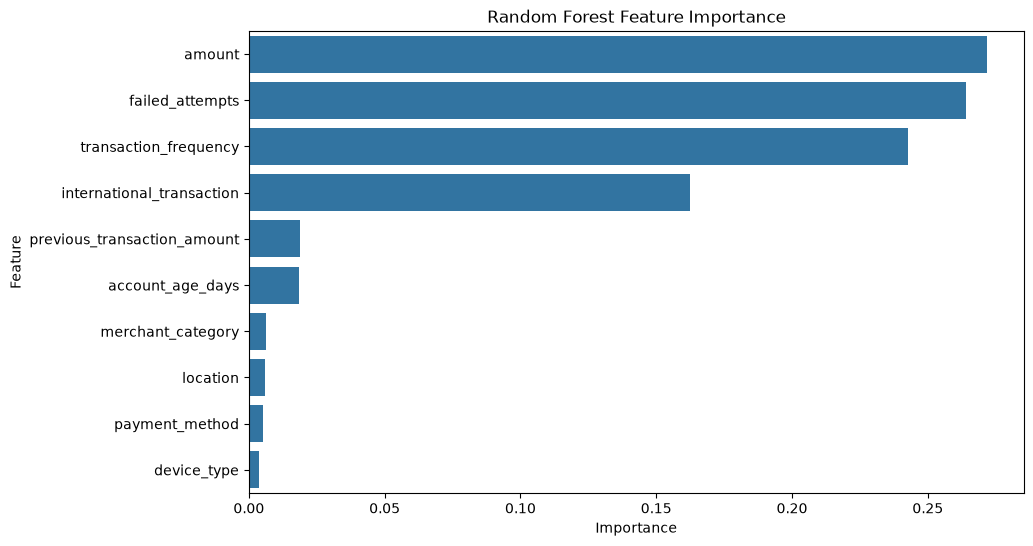

<Figure size 600x500 with 0 Axes>

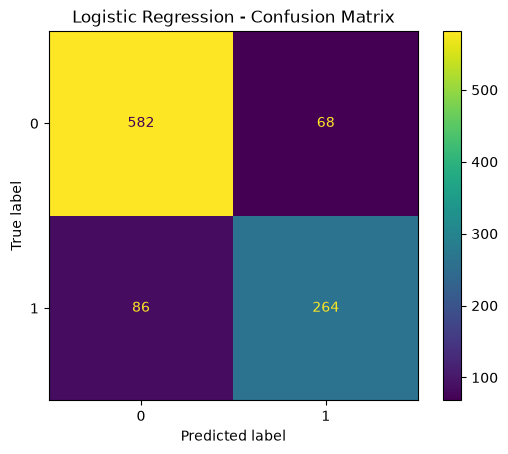

<Figure size 600x500 with 0 Axes>

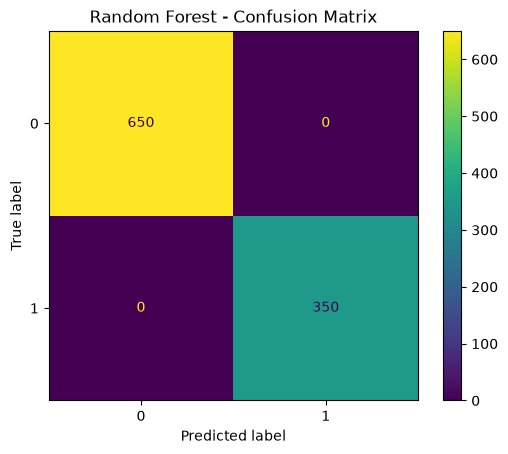

In [9]:
# ==========================================
# STEP 6 - MODEL ANALYSIS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# ------------------------------------------
# 1. Compare Model Performance
# ------------------------------------------

logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(y_test, logistic_pred, zero_division=0)
logistic_recall = recall_score(y_test, logistic_pred, zero_division=0)
logistic_f1 = f1_score(y_test, logistic_pred, zero_division=0)

rf_accuracy = accuracy_score(y_test, random_forest_pred)
rf_precision = precision_score(y_test, random_forest_pred, zero_division=0)
rf_recall = recall_score(y_test, random_forest_pred, zero_division=0)
rf_f1 = f1_score(y_test, random_forest_pred, zero_division=0)

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1
    ]
})

print("========== MODEL COMPARISON ==========")
display(model_comparison.round(4))


# ------------------------------------------
# 2. Random Forest Feature Importance
# ------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========")
display(feature_importance)


# ------------------------------------------
# 3. Feature Importance Plot
# ------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


# ------------------------------------------
# 4. Logistic Regression Confusion Matrix
# ------------------------------------------

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# ------------------------------------------
# 5. Random Forest Confusion Matrix
# ------------------------------------------

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    random_forest_pred
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [10]:
# ==========================================
# STEP 7 - NEW TRANSACTION PREDICTION
# ==========================================

# New transaction
new_transaction = pd.DataFrame({
    "amount": [85000],
    "merchant_category": ["Electronics"],
    "payment_method": ["Credit Card"],
    "location": ["Mumbai"],
    "device_type": ["Mobile"],
    "transaction_frequency": [18],
    "account_age_days": [120],
    "previous_transaction_amount": [15000],
    "international_transaction": [1],
    "failed_attempts": [4]
})

# ------------------------------------------
# Convert categorical values using
# previously fitted LabelEncoders
# ------------------------------------------

for column in categorical_columns:
    new_transaction[column] = label_encoders[column].transform(
        new_transaction[column]
    )

# Make sure columns are in same order
new_transaction = new_transaction[X.columns]

# ------------------------------------------
# Prediction
# ------------------------------------------

prediction = random_forest_model.predict(new_transaction)[0]

probability = random_forest_model.predict_proba(
    new_transaction
)[0][1]

# ------------------------------------------
# Display result
# ------------------------------------------

print("========== FRAUD PREDICTION ==========")

if prediction == 1:
    print("Prediction: FRAUD")
else:
    print("Prediction: LEGITIMATE")

print(f"Fraud Probability: {probability * 100:.2f}%")

========== FRAUD PREDICTION ==========
Prediction: FRAUD
Fraud Probability: 100.00%


In [11]:
# ==========================================
# STEP 8 - AI FRAUD EXPLANATION
# ==========================================

def generate_fraud_explanation(transaction, prediction, probability):

    reasons = []

    # Check suspicious factors
    if transaction["amount"] > 70000:
        reasons.append("The transaction amount is unusually high.")

    if transaction["international_transaction"] == 1:
        reasons.append("The transaction is international.")

    if transaction["failed_attempts"] >= 3:
        reasons.append("There are multiple failed transaction attempts.")

    if transaction["transaction_frequency"] >= 15:
        reasons.append("The transaction frequency is unusually high.")

    if transaction["previous_transaction_amount"] < transaction["amount"] * 0.3:
        reasons.append("The current amount is significantly higher than the previous transaction amount.")

    # --------------------------------------
    # Generate explanation
    # --------------------------------------

    print("\n========== AI FRAUD ANALYSIS ==========")

    if prediction == 1:

        print("Risk Status: HIGH RISK")
        print(f"Fraud Probability: {probability * 100:.2f}%")

        print("\nWhy was this transaction flagged?")

        for i, reason in enumerate(reasons, 1):
            print(f"{i}. {reason}")

        print("\nAI Recommendation:")
        print(
            "The transaction should be reviewed before approval. "
            "Additional verification may be required."
        )

    else:

        print("Risk Status: LOW RISK")
        print(f"Fraud Probability: {probability * 100:.2f}%")

        print("\nAI Analysis:")
        print(
            "No major suspicious patterns were identified "
            "based on the available transaction features."
        )

        print("\nAI Recommendation:")
        print(
            "The transaction can proceed with normal monitoring."
        )


# Run AI explanation
generate_fraud_explanation(
    new_transaction.iloc[0],
    prediction,
    probability
)


========== AI FRAUD ANALYSIS ==========
Risk Status: HIGH RISK
Fraud Probability: 100.00%

Why was this transaction flagged?
1. The transaction amount is unusually high.
2. The transaction is international.
3. There are multiple failed transaction attempts.
4. The transaction frequency is unusually high.
5. The current amount is significantly higher than the previous transaction amount.

AI Recommendation:
The transaction should be reviewed before approval. Additional verification may be required.


In [12]:
from IPython.display import FileLink

FileLink("fraud_detection_dataset.csv")

C:\Users\user\fraud_detection_dataset.csv

In [13]:
from IPython.display import FileLink

FileLink("fraud_detection_powerbi.csv")


C:\Users\user\fraud_detection_powerbi.csv

In [14]:
import os

print(os.path.exists("fraud_detection_powerbi.csv"))

True


In [15]:
# Create Power BI CSV file again

data.to_csv("fraud_detection_powerbi.csv", index=False)

print("File created successfully!")

File created successfully!


In [16]:
import os

print(os.path.exists("fraud_detection_powerbi.csv"))

True


In [17]:
from IPython.display import FileLink

FileLink("fraud_detection_powerbi.csv")

C:\Users\user\fraud_detection_powerbi.csv

In [19]:
powerbi_df = df.copy()

powerbi_df.to_csv(
    "fraud_detection_powerbi_original.csv",
    index=False
)

print("Power BI file created successfully!")
print(powerbi_df.head())

Power BI file created successfully!
   transaction_id    amount merchant_category payment_method   location  \
0          100001  37516.56            Travel            UPI      Delhi   
1          100002  95076.36            Travel            UPI  Bangalore   
2          100003  73226.19        Healthcare    Net Banking  Bangalore   
3          100004  59905.98       Electronics            UPI      Delhi   
4          100005  15686.26            Travel    Credit Card  Bangalore   

  device_type  transaction_frequency  account_age_days  \
0      Tablet                     17               370   
1      Laptop                     17              1514   
2      Mobile                     17              1445   
3      Laptop                     16              1590   
4      Laptop                      8              1604   

   previous_transaction_amount  international_transaction  failed_attempts  \
0                     10075.97                          0                2   
1       

In [20]:
!pip install openai

In [21]:
import os
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

print("API key configured successfully.")

KeyboardInterrupt: Interrupted by user

In [22]:
def ai_fraud_analysis(transaction, prediction, probability):

    print("\n========== AI FRAUD ANALYSIS ==========")

    risk_percentage = probability * 100

    if prediction == 1:
        print("Risk Status: HIGH RISK")
    else:
        print("Risk Status: LOW RISK")

    print(f"Fraud Probability: {risk_percentage:.2f}%")

    print("\nRisk Factors:")

    if transaction["amount"] > 70000:
        print("- High transaction amount")

    if transaction["international_transaction"] == 1:
        print("- International transaction")

    if transaction["failed_attempts"] >= 3:
        print("- Multiple failed attempts")

    if transaction["transaction_frequency"] >= 15:
        print("- High transaction frequency")

    if transaction["previous_transaction_amount"] < transaction["amount"] * 0.3:
        print("- Current amount is much higher than previous transaction")

    print("\nRecommendation:")

    if prediction == 1:
        print("Transaction should be reviewed and additional verification is recommended.")
    else:
        print("Transaction can proceed with normal monitoring.")

In [23]:
ai_fraud_analysis(
    new_transaction.iloc[0],
    prediction,
    probability
)


========== AI FRAUD ANALYSIS ==========
Risk Status: HIGH RISK
Fraud Probability: 100.00%

Risk Factors:
- High transaction amount
- International transaction
- Multiple failed attempts
- High transaction frequency
- Current amount is much higher than previous transaction

Recommendation:
Transaction should be reviewed and additional verification is recommended.


In [24]:
result = new_transaction.copy()

result["prediction"] = prediction
result["fraud_probability"] = probability

result["risk_level"] = (
    "HIGH RISK" if prediction == 1 else "LOW RISK"
)

result["recommendation"] = (
    "Review transaction and perform additional verification."
    if prediction == 1
    else "Proceed with normal monitoring."
)

print("========== FINAL FRAUD DETECTION RESULT ==========")
display(result)

========== FINAL FRAUD DETECTION RESULT ==========


,amount,merchant_category,payment_method,location,device_type,transaction_frequency,account_age_days,previous_transaction_amount,international_transaction,failed_attempts,prediction,fraud_probability,risk_level,recommendation
0,85000,0,0,4,1,18,120,15000,1,4,1,1.0,HIGH RISK,Review transaction and perform additional veri...


In [25]:
result.to_csv("fraud_prediction_result.csv", index=False)

print("Fraud prediction result saved successfully!")
print("File name: fraud_prediction_result.csv")

Fraud prediction result saved successfully!
File name: fraud_prediction_result.csv


In [26]:
import joblib

joblib.dump(random_forest_model, "fraud_detection_random_forest.pkl")
joblib.dump(label_encoders, "fraud_label_encoders.pkl")
joblib.dump(X.columns.tolist(), "fraud_feature_columns.pkl")

print("Model saved successfully!")
print("Random Forest model: fraud_detection_random_forest.pkl")
print("Label encoders: fraud_label_encoders.pkl")
print("Feature columns: fraud_feature_columns.pkl")

Model saved successfully!
Random Forest model: fraud_detection_random_forest.pkl
Label encoders: fraud_label_encoders.pkl
Feature columns: fraud_feature_columns.pkl
